In [2]:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sys
import os

# Get the current working directory (where the notebook is located)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)

from data_creator import load_2D
df = load_2D().dropna() # load data from files


In [3]:

#%pip install xgboost
#!brew install libomp

X = df[['Area', 'Circumference', 'CoA', 'MU', "Span", "MCS"]]

scale = StandardScaler()
scaled_X = scale.fit_transform(X)
y = df["AD"] > df["ADPass"]
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size = 0.25, random_state = 42)


In [7]:
# Train XGBoost
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)
xgb_clf.fit(X_train, y_train)

# Predictions
y_pred = xgb_clf.predict(X_test)
y_proba = xgb_clf.predict_proba(X_test)[:, 1]
np.save("preds_xgb_binary.npy", y_proba)
np.save("true_xgb_binary.npy", y_test)

/Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [16:07:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [8]:
accuracy = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

In [6]:
print("📊 XGBoost Classifier Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC : {roc:.4f}")

📊 XGBoost Classifier Results:
Accuracy: 0.9390
ROC AUC : 0.8524


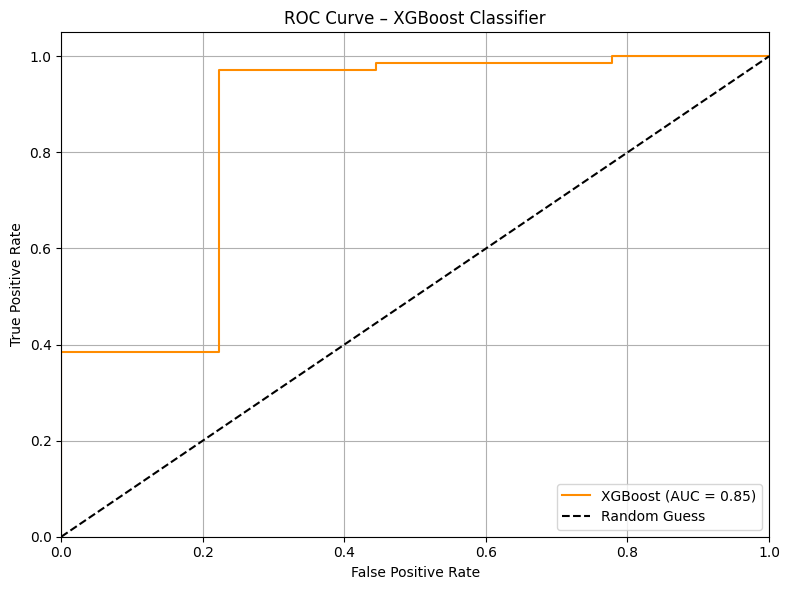

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# --- Plot ROC ---
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.2f})", color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost Classifier")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("xgboost_roc_curve.png")
plt.show()


In [12]:
import numpy as np

print(np.unique(y_proba))   # how many distinct probability values?


[0.04184335 0.07280163 0.11959593 0.12020171 0.16640909 0.16792223
 0.61998683 0.6276947  0.6278615  0.6470688  0.6892566  0.70025325
 0.7763066  0.88477325 0.8880415  0.8923174  0.8961824  0.9490217
 0.9547727  0.9566339  0.964626   0.98099625 0.9815431  0.9840163
 0.9845879  0.98957247 0.99134386 0.99219465 0.9926521  0.9934907
 0.9939498  0.9949531  0.9950045  0.99534696 0.9954724  0.9958769
 0.99611926 0.99644333 0.9965429  0.99685293 0.9969311  0.99696165
 0.9972156  0.9973808  0.9978607  0.9979233  0.9979511  0.9979527
 0.99800223 0.998475   0.9985158  0.9989378  0.9989447  0.99896896
 0.99902403 0.9990803  0.99912554 0.9991278  0.99914956 0.9991671
 0.99917334 0.99924624 0.9992797  0.99929357]


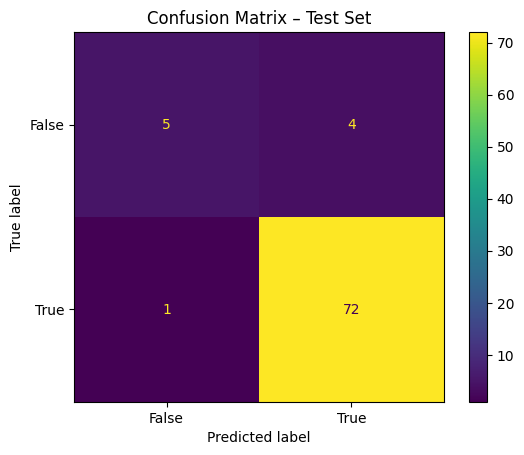

In [17]:
# Confusion Matrix
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
cm.ax_.set_title("Confusion Matrix – Test Set")
plt.show()

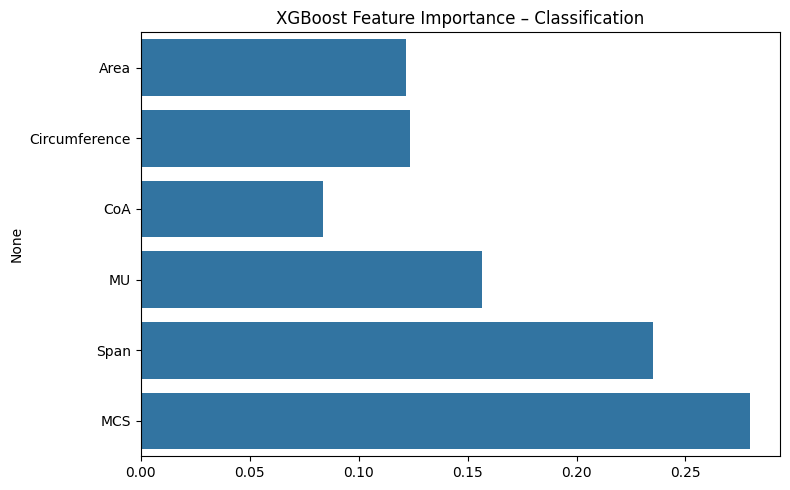

In [18]:
# Feature Importance
feat_importance = pd.Series(xgb_clf.feature_importances_, index=X.columns)
plt.figure(figsize=(8, 5))
sns.barplot(x=feat_importance.values, y=feat_importance.index)
plt.title("XGBoost Feature Importance – Classification")
plt.tight_layout()
plt.show()